# Example-20: Uncertainty estimation with error propagation and fit

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [3]:
# Estimate frequency and amplitude uncertainty from multiple noise realizations

# Set parameters

length = 1024

# Set signal (harmonic signal with two components)

time = torch.linspace(1, length, length, dtype=dtype, device=device)
signal = 1.0*torch.cos(2.0*numpy.pi*0.12345*time) + 0.1*torch.cos(2.0*numpy.pi*2.0*0.12345*time)

# Set TbT (signal copies with different noise realizations)

std = 0.10
w = Window.from_cosine(length, 1.0, dtype=dtype, device=device)
data = torch.stack([signal + std*torch.randn(length, dtype=dtype, device=device) for _ in range(1024)])
d = Data.from_data(w, data)

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Estimate frequency

f = Frequency(d)
f('parabola')
m_f, s_f = f.frequency.mean().cpu().item(), f.frequency.std().cpu().item()

# Reset work

d.reset()

# Print result

print(f'frequency: error={abs(0.12345 - m_f):<16.12}, spread={s_f:<16.12}')

# Estimate amplitude

c = 2.0/w.total*torch.sum(torch.cos(2.0*numpy.pi*m_f*time)*d.data*w.window, 1)
s = 2.0/w.total*torch.sum(torch.sin(2.0*numpy.pi*m_f*time)*d.data*w.window, 1)
a = torch.sqrt(c*c + s*s)
m_a, s_a = a.mean().cpu().item(), a.std().cpu().item()

# Print result

print(f'amplitude: error={abs(1.0 - m_a):<16.12}, spread={s_a:<16.12}')

frequency: error=8.60294756405e-08, spread=3.57249778489e-06
amplitude: error=5.80801129143e-05, spread=0.00567066142144


In [4]:
# Estimate amplitude uncertainty from one signal using error propagation
# Noise sigma is assumed to be known
# Frequency uncertainty contribution (generaly small) is ignored here

# Amplitude

def get_amplitude(frequency, signal):
    c = 2.0/w.total*torch.sum(torch.cos(2.0*numpy.pi*frequency*time)*signal*w.window)
    s = 2.0/w.total*torch.sum(torch.sin(2.0*numpy.pi*frequency*time)*signal*w.window)
    return torch.sqrt(c*c + s*s)

# Set signal

signal = torch.zeros(length, dtype=dtype, device=device)
signal, *_ = d
get_amplitude(m_f, signal)
signal.requires_grad_(True)
signal.grad = None

# Set covariance matrix

m = std**2 + torch.zeros(length, dtype=dtype, device=device)
m = torch.diag(m)

# Compute amplitude and gradient

a = get_amplitude(m_f, signal)
a.backward()
g = signal.grad

# Compute and compare uncertainty estimation

print(s_a)
print(torch.sqrt(torch.dot(g, torch.matmul(m, g))).detach().cpu().item())

0.005670661421444227
0.005412658773651794


w_min/w_max = 0.9900721048541212


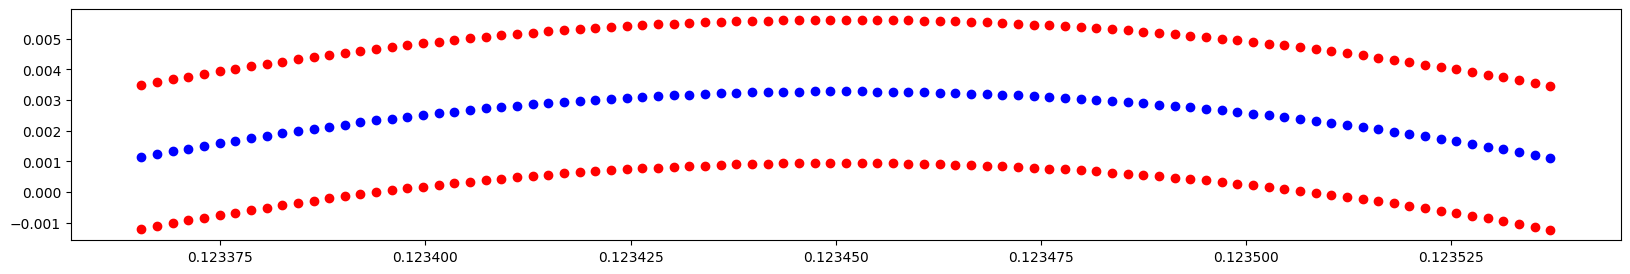

STD: 3.57249778489e-06
OLS: 3.32263272972e-06
WLS: 3.32263381205e-06


In [5]:
# Estimate frequency uncertainty from one signal using error propagation
# Noise sigma is assumed to be known if used
# For frequency, gradient can't be computed directry, since frequency estimation is an argmax problem
# In this case, for several frequencies near expected maximum location, corresponding DTFT amplitudes are computed
# A parabola can be then fitted and standart errors for coefficients can be estimated
# Error propagation can be used for each frequency value (or for minimum location), then (weighted) fit can be used
# In this example OLS and WLS are used from statsmodels library
# Note, such frequency uncertainty estimation might not br particularly accurate
# It depends on selected grid of frequencies
# Still, the order of magnitude can be somewhat meaningful

# Set a grid of frequencies near expected maximum
# Note, here ffrft grid is used for the 1st signal in TbT
# Here, grid points within given amplitude threshold

limit = 0.995
index, *_ = f.ffrft_bin.to(torch.int32)
data, *_ = f.ffrft_spectrum
grid = f.ffrft_get_grid()[limit*data[index] - data < 0]

# Set signal

signal = torch.zeros(length, dtype=dtype, device=device)
signal, *_ = d
signal.requires_grad_(True)

# Set covariance matrix

m = std**2 + torch.zeros(length, dtype=dtype, device=device)
m = torch.diag(m)

# Amplitude (log10)

def get_amplitude(frequency, signal):
    c = 2.0/w.total*torch.sum(torch.cos(2.0*numpy.pi*frequency*time)*signal*w.window)
    s = 2.0/w.total*torch.sum(torch.sin(2.0*numpy.pi*frequency*time)*signal*w.window)
    return torch.log10(torch.sqrt(c*c + s*s))

# Compute amplitude and weight for each frequency

X = []
y = []
weight = []
for frequency in grid:
    X.append([frequency.cpu().item()**2, frequency.cpu().item(), 1.0])
    a = get_amplitude(frequency, signal)
    a.backward()
    g = signal.grad
    y.append(a.cpu().item())
    weight.append(1/torch.dot(g, torch.matmul(m, g)).detach().cpu().item())
    signal.grad = None
    
# Note, weights are close to one, i.e. OLS and WLS should be close

print(f'w_min/w_max = {min(weight)/max(weight)}')

# Plot amplitudes

plt.figure(figsize=(20, 3))
plt.scatter(grid.cpu(), y - numpy.sqrt(1/numpy.array(weight)), color='red')
plt.scatter(grid.cpu(), y, color='blue')
plt.scatter(grid.cpu(), y + numpy.sqrt(1/numpy.array(weight)), color='red')
plt.show()

# Fit

from statsmodels.api import OLS, WLS
ols = OLS(y, X).fit()
wls = WLS(y, X, weights=numpy.array(weight)).fit()

# Print results

print(f'STD: {s_f:<16.12}')

a, b, c = ols.params
s_a, s_b, s_c = ols.bse
sigma = 1.0/(2.0*a**2)*numpy.sqrt(b**2*s_a**2+a**2*s_b**2)
print(f'OLS: {sigma:<16.12}')

a, b, c = wls.params
s_a, s_b, s_c = ols.bse
sigma = 1.0/(2.0*a**2)*numpy.sqrt(b**2*s_a**2+a**2*s_b**2)
print(f'WLS: {sigma:<16.12}')

# Note, this uncertainty estimation can be used to do weighted fit for different BPMs

In [6]:
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.381e+09
Date:                Fri, 04 Aug 2023   Prob (F-statistic):               0.00
Time:                        12:22:38   Log-Likelihood:                 1323.2
No. Observations:                  91   AIC:                            -2640.
Df Residuals:                      88   BIC:                            -2633.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1         -2.925e+05      5.566  -5.25e+04      0.0

In [7]:
print(wls.summary())

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.380e+09
Date:                Fri, 04 Aug 2023   Prob (F-statistic):               0.00
Time:                        12:22:41   Log-Likelihood:                 1323.3
No. Observations:                  91   AIC:                            -2641.
Df Residuals:                      88   BIC:                            -2633.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1         -2.925e+05      5.567  -5.25e+04      0.0